In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Modelo de Aprendizaje Automático y análisis de resultados

# Modelo de Aprendizaje Automático y análisis de resultados

Esta sección continúa el trabajo desarrollado en la Entrega 1 y la Entrega 2.

En la Entrega 1 se formuló el problema de trabajo: estimar la producción mensual de gas convencional.

En la Entrega 2 se describió el dataset, su origen y el recorte aplicado sobre provincias patagónicas productoras de gas.

En esta Entrega 3 se presenta el análisis exploratorio, la preparación de variables, el entrenamiento de modelos de Aprendizaje Automático y la interpretación de los resultados obtenidos.

In [21]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [23]:
ruta_raw = "/content/drive/MyDrive/parcial_producciongas/data/raw"

os.listdir(ruta_raw)

['produccin-gas-sesco-tight-y-shale-captulo-iv-por-provincia.csv']

In [24]:
ruta_csv = "/content/drive/MyDrive/parcial_producciongas/data/raw/produccin-gas-sesco-tight-y-shale-captulo-iv-por-provincia.csv"

df = pd.read_csv(ruta_csv)

df.head()

,anio,mes,indice_tiempo,provincia,concepto,cantidad_mm3
0,2009,1,2009-01,Chubut,Producción convencional,282104.3085
1,2009,1,2009-01,Chubut,Shale gas,0.0000
2,2009,1,2009-01,Chubut,Tight gas,0.0000
3,2009,1,2009-01,Estado Nacional,Producción convencional,141411.1200
4,2009,1,2009-01,Estado Nacional,Shale gas,0.0000


In [25]:
print("Cantidad de filas y columnas:", df.shape)

df.columns

Cantidad de filas y columnas: (7494, 6)


Index(['anio', 'mes', 'indice_tiempo', 'provincia', 'concepto',
       'cantidad_mm3'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7494 entries, 0 to 7493
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anio           7494 non-null   int64  
 1   mes            7494 non-null   int64  
 2   indice_tiempo  7494 non-null   object 
 3   provincia      7494 non-null   object 
 4   concepto       7494 non-null   object 
 5   cantidad_mm3   7494 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 351.4+ KB


In [27]:
df["concepto"].value_counts()

,count
concepto,
Producción convencional,2498
Shale gas,2498
Tight gas,2498


In [28]:
df["provincia"].value_counts()

,count
provincia,
Chubut,624
Estado Nacional,624
Formosa,624
Jujuy,624
Mendoza,624
Neuquén,624
Rio Negro,624
Santa Cruz,624
Salta,624


## Recorte del dataset

Para continuar con el proyecto se trabaja sobre el dataset original de producción de gas por provincia.

El recorte seleccionado incluye únicamente la producción convencional de gas en provincias patagónicas productoras. Las provincias consideradas son Tierra del Fuego, Santa Cruz, Chubut, Río Negro y Neuquén.

Este recorte permite mantener el interés principal sobre Tierra del Fuego, pero con una base de datos más amplia para entrenar y evaluar modelos de Aprendizaje Automático.

In [29]:
provincias_patagonicas = [
    "Tierra del Fuego",
    "Santa Cruz",
    "Chubut",
    "Rio Negro",
    "Neuquén"
]

df_patagonia = df[
    (df["concepto"] == "Producción convencional") &
    (df["provincia"].isin(provincias_patagonicas))
].copy()

print("Filas y columnas del recorte:", df_patagonia.shape)

df_patagonia.head()

Filas y columnas del recorte: (1040, 6)


,anio,mes,indice_tiempo,provincia,concepto,cantidad_mm3
0,2009,1,2009-01,Chubut,Producción convencional,2.821043e+05
18,2009,1,2009-01,Neuquén,Producción convencional,1.959452e+06
21,2009,1,2009-01,Rio Negro,Producción convencional,5.983653e+04
30,2009,1,2009-01,Santa Cruz,Producción convencional,4.216456e+05
33,2009,1,2009-01,Tierra del Fuego,Producción convencional,3.430233e+05


In [30]:
df_patagonia["fecha"] = pd.to_datetime(
    df_patagonia["anio"].astype(str) + "-" + df_patagonia["mes"].astype(str) + "-01"
)

df_patagonia = df_patagonia.sort_values(["provincia", "fecha"])

df_patagonia.head()

,anio,mes,indice_tiempo,provincia,concepto,cantidad_mm3,fecha
0,2009,1,2009-01,Chubut,Producción convencional,282104.3085,2009-01-01
36,2009,2,2009-02,Chubut,Producción convencional,264674.0047,2009-02-01
72,2009,3,2009-03,Chubut,Producción convencional,293367.4051,2009-03-01
108,2009,4,2009-04,Chubut,Producción convencional,287463.9808,2009-04-01
144,2009,5,2009-05,Chubut,Producción convencional,300840.2314,2009-05-01


## EDA Análisis exploratorio de datos

En esta etapa se realiza una exploración inicial del dataset recortado. El objetivo es conocer la distribución de la producción mensual de gas convencional, comparar el comportamiento entre provincias y observar la evolución temporal de la producción.

Este análisis permite entender mejor los datos antes de entrenar un modelo de Aprendizaje Automático.

In [31]:
df_patagonia["cantidad_mm3"].describe()

,cantidad_mm3
count,1.040000e+03
mean,3.703201e+05
std,3.869332e+05
min,-4.432780e+05
25%,1.762411e+05
50%,2.821491e+05
75%,3.507570e+05
max,2.003701e+06


In [32]:
df_patagonia.groupby("provincia")["cantidad_mm3"].describe()

,count,mean,std,min,25%,50%,75%,max
provincia,,,,,,,,
Chubut,208.0,263463.930923,38856.166558,19707.381790,242164.643118,275770.269675,2.927612e+05,3.183742e+05
Neuquén,208.0,969776.206910,504722.340287,-443278.022963,537675.364722,945433.213716,1.353777e+06,2.003701e+06
Rio Negro,208.0,65775.510479,13032.079343,35072.349107,56611.691500,65060.029000,7.625064e+04,1.055004e+05
Santa Cruz,208.0,271357.735443,78652.697797,11450.565000,189655.426102,286804.730309,3.264726e+05,4.347175e+05
Tierra del Fuego,208.0,281227.069077,72801.003295,21240.170000,248374.433250,291109.826000,3.304224e+05,4.070625e+05


In [33]:
df_patagonia["provincia"].value_counts()

,count
provincia,
Chubut,208
Neuquén,208
Rio Negro,208
Santa Cruz,208
Tierra del Fuego,208


In [34]:
print("Valores faltantes por columna:")
print(df_patagonia.isnull().sum())

Valores faltantes por columna:
anio             0
mes              0
indice_tiempo    0
provincia        0
concepto         0
cantidad_mm3     0
fecha            0
dtype: int64


In [35]:
print("Tamaño del dataset usado en el EDA:")
print(df_patagonia.shape)

Tamaño del dataset usado en el EDA:
(1040, 7)


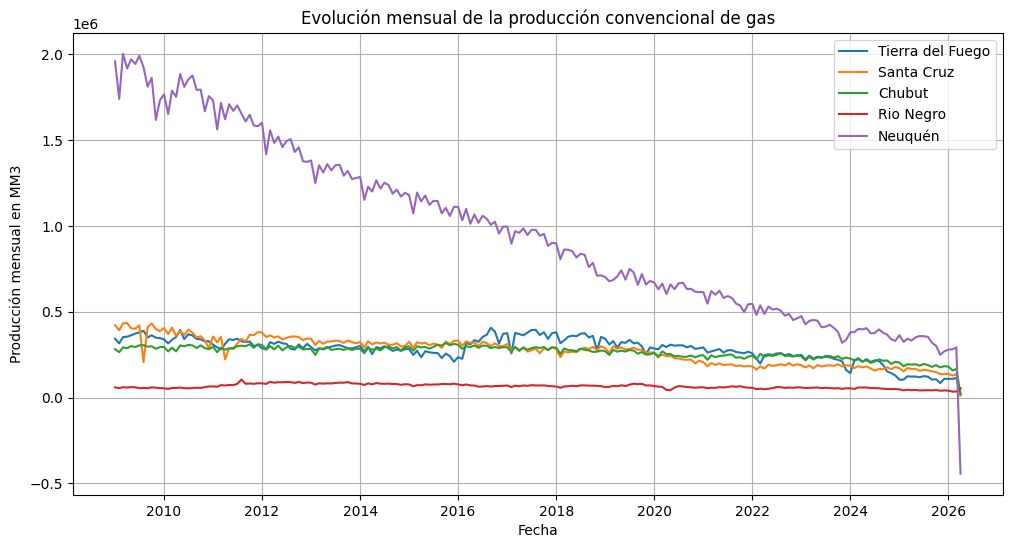

In [36]:
plt.figure(figsize=(12, 6))

for provincia in provincias_patagonicas:
    datos = df_patagonia[df_patagonia["provincia"] == provincia]
    plt.plot(datos["fecha"], datos["cantidad_mm3"], label=provincia)

plt.title("Evolución mensual de la producción convencional de gas")
plt.xlabel("Fecha")
plt.ylabel("Producción mensual en MM3")
plt.legend()
plt.grid(True)
plt.show()

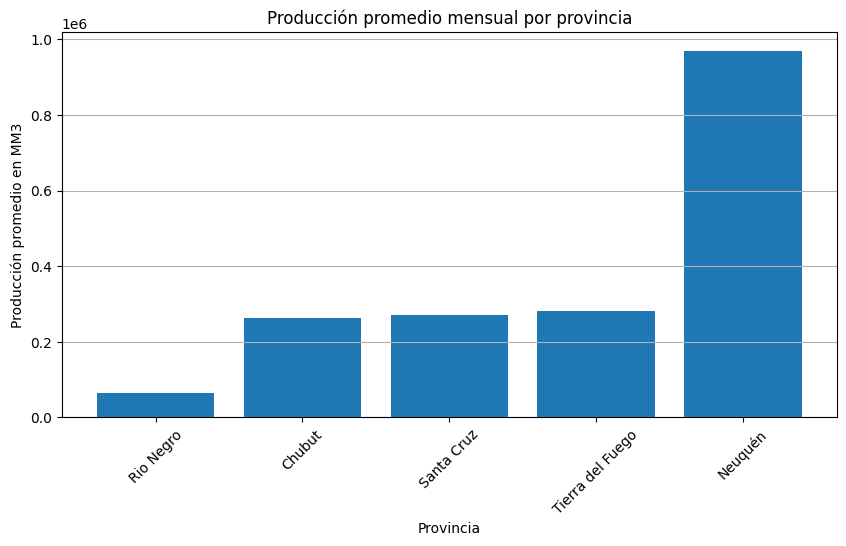

In [37]:
promedio_provincia = (
    df_patagonia
    .groupby("provincia")["cantidad_mm3"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 5))
plt.bar(promedio_provincia.index, promedio_provincia.values)

plt.title("Producción promedio mensual por provincia")
plt.xlabel("Provincia")
plt.ylabel("Producción promedio en MM3")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

/tmp/ipykernel_17008/596809476.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_boxplot, labels=provincias_patagonicas)


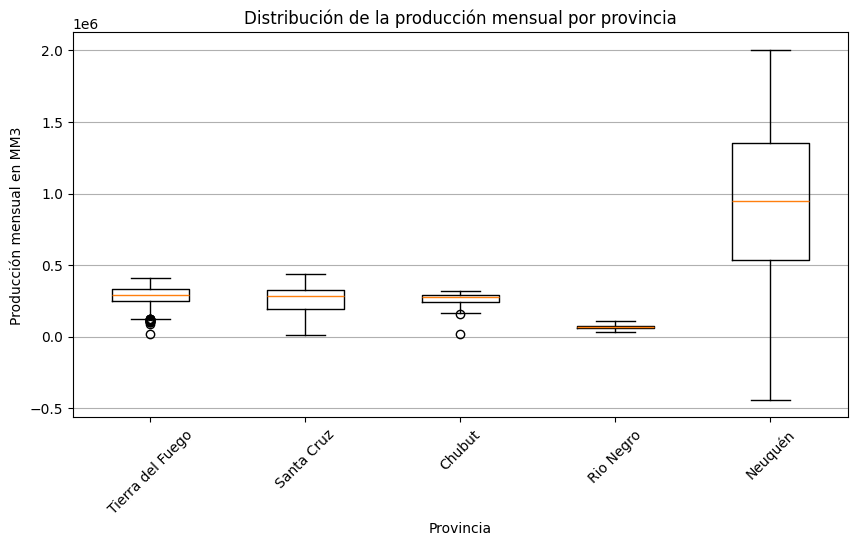

In [38]:
datos_boxplot = [
    df_patagonia[df_patagonia["provincia"] == provincia]["cantidad_mm3"]
    for provincia in provincias_patagonicas
]

plt.figure(figsize=(10, 5))
plt.boxplot(datos_boxplot, labels=provincias_patagonicas)

plt.title("Distribución de la producción mensual por provincia")
plt.xlabel("Provincia")
plt.ylabel("Producción mensual en MM3")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Conclusiones del análisis exploratorio

A partir del análisis exploratorio se observan algunas diferencias importantes entre las provincias seleccionadas.

En primer lugar, Neuquén aparece como la provincia con mayor producción promedio mensual de gas convencional dentro del recorte analizado. Sin embargo, en el gráfico de evolución temporal también se observa una tendencia descendente entre los primeros años del período y los años más recientes.

Tierra del Fuego, que era el foco inicial del proyecto, presenta niveles de producción menores en comparación con Neuquén. Su evolución se mantiene dentro de un rango más acotado, aunque con variaciones a lo largo del período analizado.

Estas diferencias muestran que la provincia es una variable relevante para el modelo, ya que la producción mensual no se comporta igual en todos los territorios. También se observa que la producción de meses anteriores puede ser útil para estimar la producción del mes actual, porque las series muestran cierta continuidad temporal.

# Preparación de variables para el modelo

Para entrenar el modelo se construyen variables históricas. La idea es utilizar información de meses anteriores para estimar la producción del mes actual.

Esto evita usar información futura y permite que el modelo aprenda a partir del comportamiento previo de cada provincia.

In [39]:
df_patagonia["produccion_mes_anterior"] = (
    df_patagonia.groupby("provincia")["cantidad_mm3"].shift(1)
)

df_patagonia["produccion_dos_meses_antes"] = (
    df_patagonia.groupby("provincia")["cantidad_mm3"].shift(2)
)

df_patagonia["promedio_3_meses"] = (
    df_patagonia.groupby("provincia")["cantidad_mm3"]
    .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

df_patagonia["variacion_mes_anterior"] = (
    df_patagonia["produccion_mes_anterior"] -
    df_patagonia["produccion_dos_meses_antes"]
)

df_patagonia.head()

,anio,mes,indice_tiempo,provincia,concepto,cantidad_mm3,fecha,produccion_mes_anterior,produccion_dos_meses_antes,promedio_3_meses,variacion_mes_anterior
0,2009,1,2009-01,Chubut,Producción convencional,282104.3085,2009-01-01,NaN,NaN,NaN,NaN
36,2009,2,2009-02,Chubut,Producción convencional,264674.0047,2009-02-01,282104.3085,NaN,NaN,NaN
72,2009,3,2009-03,Chubut,Producción convencional,293367.4051,2009-03-01,264674.0047,282104.3085,NaN,-17430.3038
108,2009,4,2009-04,Chubut,Producción convencional,287463.9808,2009-04-01,293367.4051,264674.0047,280048.572767,28693.4004
144,2009,5,2009-05,Chubut,Producción convencional,300840.2314,2009-05-01,287463.9808,293367.4051,281835.130200,-5903.4243


In [40]:
df_ml = df_patagonia.dropna().copy()

print("Filas y columnas del dataset para ML:", df_ml.shape)

df_ml.head()

Filas y columnas del dataset para ML: (1025, 11)


,anio,mes,indice_tiempo,provincia,concepto,cantidad_mm3,fecha,produccion_mes_anterior,produccion_dos_meses_antes,promedio_3_meses,variacion_mes_anterior
108,2009,4,2009-04,Chubut,Producción convencional,287463.9808,2009-04-01,293367.4051,264674.0047,280048.572767,28693.4004
144,2009,5,2009-05,Chubut,Producción convencional,300840.2314,2009-05-01,287463.9808,293367.4051,281835.130200,-5903.4243
180,2009,6,2009-06,Chubut,Producción convencional,294138.6128,2009-06-01,300840.2314,287463.9808,293890.539100,13376.2506
216,2009,7,2009-07,Chubut,Producción convencional,304828.4822,2009-07-01,294138.6128,300840.2314,294147.608333,-6701.6186
252,2009,8,2009-08,Chubut,Producción convencional,305871.6603,2009-08-01,304828.4822,294138.6128,299935.775467,10689.8694


## Variable objetivo y variables predictoras

La variable objetivo del modelo es `cantidad_mm3`, que representa la producción mensual de gas convencional.

Las variables predictoras utilizadas son:

- año
- mes
- provincia
- producción del mes anterior
- producción de dos meses antes
- promedio de los tres meses anteriores
- variación entre meses anteriores

Estas variables permiten entrenar un modelo de regresión usando información histórica disponible antes del mes que se quiere estimar.

In [46]:
features = [
    "anio",
    "mes",
    "provincia",
    "produccion_mes_anterior",
    "produccion_dos_meses_antes",
    "promedio_3_meses",
    "variacion_mes_anterior"
]

target = "cantidad_mm3"

X = df_ml[features]
y = df_ml[target]

X.head()

,anio,mes,provincia,produccion_mes_anterior,produccion_dos_meses_antes,promedio_3_meses,variacion_mes_anterior
0,2009,4,Chubut,293367.4051,264674.0047,280048.572767,28693.4004
1,2009,5,Chubut,287463.9808,293367.4051,281835.130200,-5903.4243
2,2009,6,Chubut,300840.2314,287463.9808,293890.539100,13376.2506
3,2009,7,Chubut,294138.6128,300840.2314,294147.608333,-6701.6186
4,2009,8,Chubut,304828.4822,294138.6128,299935.775467,10689.8694


## Separación entre entrenamiento y prueba

Como los datos tienen una dimensión temporal, se decidió separar entrenamiento y prueba respetando el orden de los meses.

Se utiliza aproximadamente el 80% inicial del período para entrenar el modelo y el 20% final para evaluarlo. De esta manera, el modelo aprende con datos históricos y se prueba sobre meses posteriores.

In [47]:
fechas_ordenadas = sorted(df_ml["fecha"].unique())

punto_corte = fechas_ordenadas[int(len(fechas_ordenadas) * 0.8)]

train = df_ml[df_ml["fecha"] < punto_corte]
test = df_ml[df_ml["fecha"] >= punto_corte]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Fecha de corte:", punto_corte)
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Fecha de corte: 2022-12-01 00:00:00
Tamaño entrenamiento: (820, 7)
Tamaño prueba: (205, 7)


## Modelos utilizados

Para esta entrega se entrenan dos modelos de aprendizaje supervisado orientados a regresión.

El primer modelo es una regresión lineal, que se utiliza como modelo principal por estar vinculada directamente con los contenidos trabajados en la materia.

El segundo modelo es un árbol de decisión para regresión, utilizado como comparación. Este modelo permite observar si una estructura no lineal mejora o no los resultados frente a la regresión lineal.

La variable `provincia` es una variable categórica, por lo que se transforma mediante One Hot Encoding antes del entrenamiento.

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Codificación de la variable categórica provincia
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocesamiento = ColumnTransformer(
    transformers=[
        ("provincia", encoder, ["provincia"])
    ],
    remainder="passthrough"
)

# Modelo 1: Regresión lineal
modelo_regresion_lineal = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", LinearRegression())
    ]
)

# Modelo 2: Árbol de decisión
modelo_arbol = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", DecisionTreeRegressor(max_depth=5, random_state=42))
    ]
)

modelo_regresion_lineal.fit(X_train, y_train)
modelo_arbol.fit(X_train, y_train)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


In [58]:
import joblib
import os

ruta_models = "/content/drive/MyDrive/parcial_producciongas/models"
os.makedirs(ruta_models, exist_ok=True)

joblib.dump(modelo_regresion_lineal, f"{ruta_models}/modelo_regresion_lineal.joblib")
joblib.dump(modelo_arbol, f"{ruta_models}/modelo_arbol_decision.joblib")

print("Modelos guardados correctamente en:", ruta_models)
print(os.listdir(ruta_models))

Modelos guardados correctamente en: /content/drive/MyDrive/parcial_producciongas/models
['modelo_regresion_lineal.joblib', 'modelo_arbol_decision.joblib']


## Evaluación de los modelos

Como el problema trabajado es de regresión, la variable objetivo no es una categoría sino un valor numérico continuo, es decir la producción mensual de gas convencional.

Por ese motivo, en lugar de usar métricas de clasificación como precisión, recall o F1-score, se evalúa el error entre el valor real y el valor predicho por el modelo.

Las métricas utilizadas son:

- MAE: error absoluto medio.
- RMSE: raíz del error cuadrático medio.
- R2: nivel de ajuste del modelo respecto de los datos reales.

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_modelo(nombre, modelo, X_test, y_test):
    predicciones = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, predicciones)
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    r2 = r2_score(y_test, predicciones)

    return {
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

resultados = [
    evaluar_modelo("Regresión lineal", modelo_regresion_lineal, X_test, y_test),
    evaluar_modelo("Árbol de decisión", modelo_arbol, X_test, y_test)
]

resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,MAE,RMSE,R2
0,Regresión lineal,15675.247922,54951.131690,0.784454
1,Árbol de decisión,24507.342708,59600.563437,0.746436


## Interpretación de las métricas

A partir de los resultados obtenidos, el modelo de regresión lineal presentó un mejor desempeño que el árbol de decisión.

La regresión lineal obtuvo un MAE de aproximadamente 15.675 MM3, mientras que el árbol de decisión obtuvo un MAE de aproximadamente 24.507 MM3. Esto indica que, en promedio, la regresión lineal cometió un error menor al estimar la producción mensual de gas convencional.

También se observa que la regresión lineal obtuvo un RMSE menor que el árbol de decisión. Esto significa que, además de tener menor error promedio, también presentó un mejor comportamiento frente a errores más grandes.

En cuanto al valor de R2, la regresión lineal alcanzó un valor aproximado de 0,78. Esto indica que el modelo logra explicar una parte importante de la variación de la producción mensual, aunque todavía queda margen de error. El árbol de decisión obtuvo un R2 aproximado de 0,74, por lo que también tuvo un desempeño aceptable, pero inferior al de la regresión lineal.

Por estos motivos, se selecciona la regresión lineal como modelo principal para esta entrega.


In [50]:
predicciones_lineal = modelo_regresion_lineal.predict(X_test)

comparacion = test.copy()
comparacion["produccion_real"] = y_test
comparacion["produccion_predicha"] = predicciones_lineal
comparacion["error_absoluto"] = abs(
    comparacion["produccion_real"] - comparacion["produccion_predicha"]
)

comparacion[
    ["fecha", "provincia", "produccion_real", "produccion_predicha", "error_absoluto"]
].head(20)

,fecha,provincia,produccion_real,produccion_predicha,error_absoluto
164,2022-12-01,Chubut,247198.986520,237624.981549,9574.004971
165,2023-01-01,Chubut,240936.346860,243786.451156,2850.104296
166,2023-02-01,Chubut,217285.433700,244156.827936,26871.394236
167,2023-03-01,Chubut,237640.503088,234860.192227,2780.310861
168,2023-04-01,Chubut,222136.755500,227735.500330,5598.744830
169,2023-05-01,Chubut,234559.328600,227820.064201,6739.264399
170,2023-06-01,Chubut,231625.191120,227384.163311,4241.027809
171,2023-07-01,Chubut,242738.789600,228997.378606,13741.410994
172,2023-08-01,Chubut,242521.686800,232774.185963,9747.500837
173,2023-09-01,Chubut,233624.698070,236998.503315,3373.805245


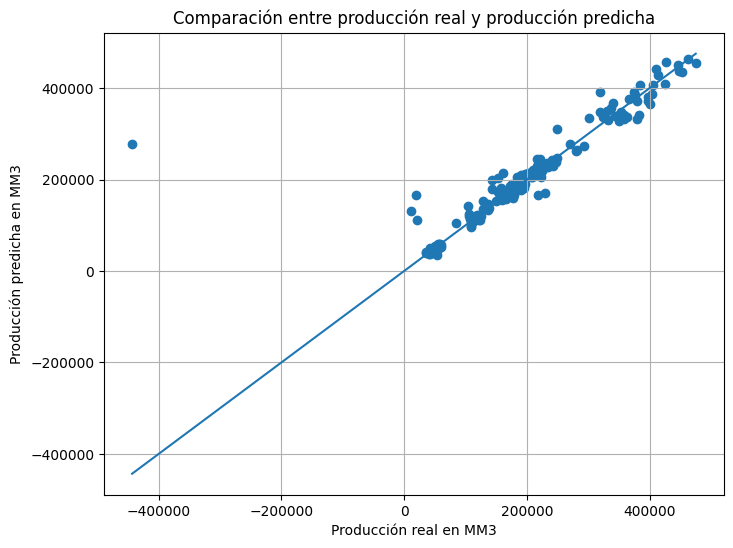

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparacion["produccion_real"],
    comparacion["produccion_predicha"]
)

valor_min = min(comparacion["produccion_real"].min(), comparacion["produccion_predicha"].min())
valor_max = max(comparacion["produccion_real"].max(), comparacion["produccion_predicha"].max())

plt.plot([valor_min, valor_max], [valor_min, valor_max])

plt.title("Comparación entre producción real y producción predicha")
plt.xlabel("Producción real en MM3")
plt.ylabel("Producción predicha en MM3")
plt.grid(True)
plt.show()

In [52]:
comparacion_tdf = comparacion[comparacion["provincia"] == "Tierra del Fuego"].copy()

comparacion_tdf[
    ["fecha", "provincia", "produccion_real", "produccion_predicha", "error_absoluto"]
].head()

,fecha,provincia,produccion_real,produccion_predicha,error_absoluto
984,2022-12-01,Tierra del Fuego,244718.386,243800.042730,918.343270
985,2023-01-01,Tierra del Fuego,248579.128,246212.816368,2366.311632
986,2023-02-01,Tierra del Fuego,222147.548,245738.248417,23590.700417
987,2023-03-01,Tierra del Fuego,244587.437,239440.377723,5147.059277
988,2023-04-01,Tierra del Fuego,227376.256,233543.702757,6167.446757


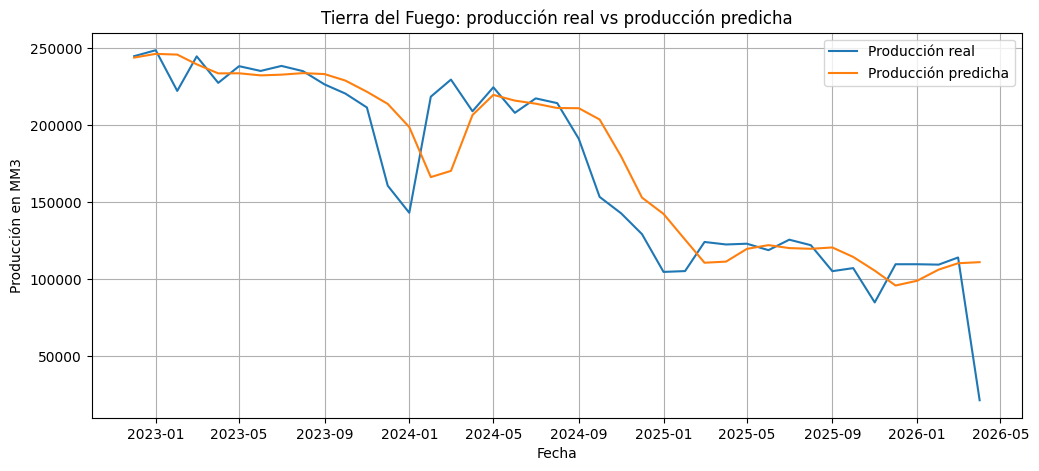

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparacion_tdf["fecha"],
    comparacion_tdf["produccion_real"],
    label="Producción real"
)

plt.plot(
    comparacion_tdf["fecha"],
    comparacion_tdf["produccion_predicha"],
    label="Producción predicha"
)

plt.title("Tierra del Fuego: producción real vs producción predicha")
plt.xlabel("Fecha")
plt.ylabel("Producción en MM3")
plt.legend()
plt.grid(True)
plt.show()

## Interpretación de los resultados del modelo

El modelo de regresión lineal logra aproximarse razonablemente a los valores reales de producción mensual de gas convencional. No se trata de un modelo perfecto, pero permite observar que las variables históricas, como la producción del mes anterior y el promedio de los meses previos, aportan información útil para estimar la producción del mes actual.

En el caso de Tierra del Fuego, el modelo permite comparar la producción real con la producción predicha durante el período de prueba. Esta comparación ayuda a evaluar si el comportamiento de la provincia puede ser aproximado a partir de los datos históricos incluidos en el dataset.

El resultado obtenido muestra que el problema formulado en la primera entrega podía abordarse como un problema de regresión. A partir del dataset seleccionado, el modelo logró estimar una variable numérica continua, que en este caso es la producción mensual de gas convencional medida en MM3.


## Conclusiones finales

En esta tercera entrega se logró completar el proceso iniciado en las entregas anteriores. En la Entrega 1 se formuló el problema como una estimación de la producción mensual de gas convencional. En la Entrega 2 se describió el dataset, su origen y el recorte aplicado sobre provincias patagónicas productoras. En esta etapa se avanzó con el análisis exploratorio, la construcción de variables, el entrenamiento de modelos y la evaluación de resultados.

El análisis exploratorio permitió observar diferencias importantes entre las provincias. Neuquén aparece como la provincia con mayor producción promedio mensual dentro del recorte trabajado, aunque también muestra una tendencia descendente a lo largo del período analizado. Tierra del Fuego, que era el foco inicial del proyecto, presenta niveles de producción menores y más acotados, con variaciones dentro de su propia serie histórica.

Para el modelo se utilizaron variables temporales y variables históricas de producción, como la producción del mes anterior, la producción de dos meses antes, el promedio de los tres meses previos y la variación entre meses anteriores. Esto permitió trabajar con información disponible antes del mes a estimar, evitando usar datos futuros.

Se entrenaron dos modelos: una regresión lineal y un árbol de decisión para regresión. A partir de las métricas obtenidas, la regresión lineal presentó mejores resultados. Obtuvo un MAE aproximado de 15.675 MM3, un RMSE aproximado de 54.951 MM3 y un R2 de 0,78. Esto indica que el modelo logra explicar una parte importante de la variación de la producción mensual, aunque todavía existen errores y margen de mejora.

El árbol de decisión también obtuvo un resultado aceptable, con un R2 de 0,74, pero presentó un error promedio mayor. Por ese motivo, se selecciona la regresión lineal como modelo principal del proyecto.

Como conclusión general, el modelo permitió abordar el problema formulado inicialmente: estimar una variable numérica continua, en este caso la producción mensual de gas convencional. El resultado no debe interpretarse como una predicción perfecta, sino como una primera aproximación realizada en el marco de un proceso de aprendizaje. El trabajo permitió aplicar etapas centrales de Aprendizaje Automático: adquisición de datos, preprocesamiento, análisis exploratorio, entrenamiento de modelos, evaluación e interpretación de resultados.


## Limitaciones del trabajo

El modelo desarrollado tiene algunas limitaciones. En primer lugar, se trabajó con un conjunto reducido de variables, principalmente temporales e históricas. No se incorporaron otras variables que podrían influir en la producción de gas, como inversiones, infraestructura, nuevos pozos, decisiones empresariales, mantenimiento, condiciones operativas o cambios regulatorios.

Además, el modelo se entrenó con datos agregados por provincia y mes, por lo que no permite analizar diferencias internas dentro de cada provincia ni comportamientos por yacimiento, empresa u operador.

Por último, esta entrega debe entenderse como una primera aproximación al problema. El objetivo principal fue aplicar un flujo básico de Aprendizaje Automático, interpretar los resultados y reconocer qué aspectos podrían mejorarse en futuras versiones.


In [54]:
ruta_resultados = "/content/drive/MyDrive/parcial_producciongas/reports/resultados_modelos_entrega_3.csv"

resultados_df.to_csv(ruta_resultados, index=False)

print("Resultados guardados en:", ruta_resultados)

Resultados guardados en: /content/drive/MyDrive/parcial_producciongas/reports/resultados_modelos_entrega_3.csv


In [55]:
ruta_comparacion = "/content/drive/MyDrive/parcial_producciongas/reports/comparacion_real_predicho_entrega_3.csv"

comparacion[
    ["fecha", "provincia", "produccion_real", "produccion_predicha", "error_absoluto"]
].to_csv(ruta_comparacion, index=False)

print("Comparación guardada en:", ruta_comparacion)

Comparación guardada en: /content/drive/MyDrive/parcial_producciongas/reports/comparacion_real_predicho_entrega_3.csv


In [56]:
import os

base = "/content/drive/MyDrive/parcial_producciongas"

for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

parcial_producciongas/
    notebooks/
        parcial_producciongas.ipynb
    data/
        raw/
            produccin-gas-sesco-tight-y-shale-captulo-iv-por-provincia.csv
        processed/
            produccin-gas-sesco-tight-y-shale-captulo-iv-por-provincia.csv
    reports/
        ENTREGA1_EVALUACIÓN PARCIAL_ APRENDIZAJE AUTOMÁTICO_GonzaloOrtiz.pdf
        Aprendizaje automático_entrega2_GonzaloOrtiz.pdf
        resultados_modelos_entrega_3.csv
        comparacion_real_predicho_entrega_3.csv
    scr/
    models/
    .git/
        description
        COMMIT_EDITMSG
        HEAD
        index
        config
        hooks/
            post-update.sample
            push-to-checkout.sample
            pre-receive.sample
            update.sample
            prepare-commit-msg.sample
            pre-push.sample
            commit-msg.sample
            pre-applypatch.sample
            fsmonitor-watchman.sample
            pre-rebase.sample
            pre-commit.sample
            